# Анализ лояльности пользователей Яндекс Афиши

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [1]:
# Инструменты для анализа
import pandas as pd
import numpy as np
from phik import phik_matrix

# Взаимодействие с БД
from sqlalchemy import create_engine

# Визуализация
from matplotlib import pyplot as plt
import seaborn as sns

# 
from dotenv import load_dotenv
from os import getenv

В корне репозитория создал файл `.env`, который содержит константы `DOTENV_USER`, `DOTENV_PWD`, `DOTENV_HOST`, `DOTENV_PORT`, `DOTENV_DB`.

In [2]:
try:
    # 1/0
    if load_dotenv():
        USER = getenv('DOTENV_USER')
        PWD = getenv('DOTENV_PWD')
        HOST = getenv('DOTENV_HOST')
        PORT = getenv('DOTENV_PORT')
        DB = getenv('DOTENV_DB')

        db_config = {'user': USER, # имя пользователя
                     'pwd': PWD, # пароль
                     'host': HOST,
                     'port': PORT, # порт подключения
                     'db': DB # название базы данных
                    }

        print('Использовали dotenv 😎')
except:
    db_config = {'user': 'praktikum_student', # имя пользователя
                 'pwd': 'Sdf4$2;d-d30pp', # пароль
                 'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
                 'port': 6432, # порт подключения
                 'db': 'data-analyst-afisha' # название базы данных
                }
    
    print('Захардкодили :(')

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
) 

Использовали dotenv 😎


In [3]:
engine = create_engine(connection_string) 

In [4]:
query = '''
SELECT
    user_id,
    device_type_canonical,
    order_id,
    created_dt_msk AS order_dt,
    created_ts_msk AS order_ts,
    currency_code,
    revenue,
    tickets_count,
    CASE
        WHEN count(*) OVER (
            PARTITION BY user_id
        ) > 1
        THEN 
            created_dt_msk::date - LAG(created_dt_msk::date) OVER (
                PARTITION BY user_id
            ORDER BY
                created_dt_msk
            )
        ELSE
            NULL
    END AS days_since_prev,
    p.event_id,
    e.event_name_code AS event_name,
    e.event_type_main,
    p.service_name,
    r.region_name,
    c.city_name
FROM
    afisha.purchases AS p
LEFT JOIN afisha.events AS e ON p.event_id = e.event_id
LEFT JOIN afisha.city AS c ON e.city_id = c.city_id
LEFT JOIN afisha.regions AS r ON c.region_id = r.region_id
WHERE
    device_type_canonical IN (
        'mobile', 'desktop'
    ) AND
    event_type_main != 'фильм'
ORDER BY
    user_id ASC
'''

In [5]:
df = pd.read_sql_query(query, con=engine) 

In [6]:
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк


---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  str           
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  str           
 11  event_type_main        290611 non-null  str           
 12  service_name           290611 non-null  str           


Представленная таблица имеет $290611$ строк и $15$ колонок. Важно учесть следующее:
- `days_since_prev` содержит пропуски. После замены их на заглушку можно преобразовать поле к целочисленному типу
- поля `device_type_canonical`, `currency_code`, `event_type_main`, `service_name`, `region_name` и `city_name` категориальные. Поля `service_name`, `region_name` и `city_name` предварительно стоит нормализовать
- `tickets_count`, в случае отсутствия выбросов, вряд ли будет содержать большие числа. Можно оптимизировать

---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

#### Задача 2.1
Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `'https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv'`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


Загрузим датафрейм:

In [8]:
kzt_rub_course = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

kzt_rub_course.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [9]:
kzt_rub_course.info()

<class 'pandas.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    str    
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    str    
dtypes: float64(1), int64(1), str(2)
memory usage: 11.3 KB


In [10]:
kzt_rub_course['data'] = pd.to_datetime(kzt_rub_course['data'], format='ISO8601')

Проверим корректность дат:

In [11]:
print(kzt_rub_course['data'].min())
print(kzt_rub_course['data'].max())

2024-01-10 00:00:00
2024-12-31 00:00:00


Посчитаем колиичество представленных дней:

In [12]:
kzt_rub_course['data'].nunique()

357

Проверим корректность поля `nominal`

In [13]:
kzt_rub_course['nominal'].count()

np.int64(357)

Разделим поля `curs` и `nominal` на `nominal`:

In [14]:
kzt_rub_course['nominal'] /= kzt_rub_course['curs']
kzt_rub_course['curs'] /= kzt_rub_course['curs']

kzt_rub_course.head()

,data,nominal,curs,cdx
0,2024-01-10,5.015272,1.0,kzt
1,2024-01-11,5.069580,1.0,kzt
2,2024-01-12,5.106235,1.0,kzt
3,2024-01-13,5.141362,1.0,kzt
4,2024-01-14,5.141362,1.0,kzt


Теперь у нас есть курс тенге к $1$ рублю. Отбросим ненужные столбцы

In [15]:
kzt_rub_course.drop(['curs', 'cdx'], axis=1, inplace=True)

kzt_rub_course.head()

,data,nominal
0,2024-01-10,5.015272
1,2024-01-11,5.069580
2,2024-01-12,5.106235
3,2024-01-13,5.141362
4,2024-01-14,5.141362


In [16]:
df = pd.merge(df, kzt_rub_course, left_on='order_dt', right_on='data')

df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,data,nominal
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск,2024-08-20,5.348394
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск,2024-07-23,5.451998
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск,2024-10-06,5.089706
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск,2024-07-13,5.405113
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк,2024-10-04,5.085228


In [17]:
df['is_kzt'] = (df['currency_code'] == 'kzt')

df[['currency_code', 'is_kzt']].sample(5)

,currency_code,is_kzt
281908,kzt,True
212736,rub,False
90073,rub,False
31261,rub,False
259639,rub,False


In [18]:
df['revenue_rub'] = df['revenue'] * (
    df['is_kzt'] * df['nominal'] + \
    (~df['is_kzt'])
)

df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,data,nominal,is_kzt,revenue_rub
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск,2024-08-20,5.348394,False,1521.94
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск,2024-07-23,5.451998,False,289.45
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск,2024-10-06,5.089706,False,1258.57
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск,2024-07-13,5.405113,False,8.49
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк,2024-10-04,5.085228,False,1390.41


In [19]:
df.drop(['data', 'nominal', 'is_kzt'], axis=1, inplace=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  str           
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  str           
 11  event_type_main        290611 non-null  str           
 12  service_name           290611 non-null  str           


---

#### Задача 2.2

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  str           
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  str           
 11  event_type_main        290611 non-null  str           
 12  service_name           290611 non-null  str           


##### Преобразование категориальных столбцов

Преобразуем категориальные поля к нужному типу. Для этого вначале нормализуем поля `service_name`, `region_name` и `city_name`:

In [21]:
df['service_name'].unique()

<StringArray>
[          'Край билетов',              'Мой билет',            'За билетом!',
            'Лови билет!',     'Билеты без проблем',                'Облачко',
          'Лучшие билеты',              'Прачечная',            'Быстробилет',
           'Дом культуры',         'Весь в билетах',          'Билеты в руки',
            'Тебе билет!',            'Show_ticket', 'Городской дом культуры',
                 'Яблоко',      'Билет по телефону',         'Выступления.ру',
               'Росбилет',        'Шоу начинается!',               'Мир касс',
              'Восьмёрка',              'Телебилет',          'Crazy ticket!',
                 'Реестр',         'Быстрый кассир',             'КарандашРУ',
           'Радио ticket',                'Дырокол',                'Вперёд!',
             'Кино билет',           'Цвет и билет',               'Зе Бест!',
              'Тех билет',                 'Лимоны',     'Билеты в интернете']
Length: 36, dtype: str

In [22]:
df['region_name'].unique()

<StringArray>
[       'Каменевский регион',      'Североярская область',
          'Озернинский край',      'Лугоградская область',
          'Поленовский край',       'Широковская область',
         'Медовская область',       'Златопольский округ',
      'Малиновоярский округ',       'Яблоневская область',
         'Ветренский регион',         'Боровлянский край',
      'Крутоводская область',      'Ягодиновская область',
     'Серебряноярский округ',          'Лесодальний край',
       'Верхоречная область',      'Горицветская область',
       'Речиновская область',         'Травиницкий округ',
        'Сосновская область',      'Серебринская область',
          'Травяная область',        'Каменноярский край',
   'Солнечноземская область',      'Светополянский округ',
          'Заречная область',         'Ручейковский край',
      'Глиногорская область',      'Тепляковская область',
       'Каменноозёрный край', 'Солнечнореченская область',
          'Зоринский регион',       'Берёз

In [23]:
df['city_name'].unique()

<StringArray>
[   'Глиногорск',        'Озёрск',   'Родниковецк',   'Кристалевск',
 'Дальнозолотск',  'Радужнополье',     'Радужсвет',        'Кумсай',
     'Верховино',    'Светополье',
 ...
    'Дальнеград',     'Горноград',   'Березовцево',     'Берёзовка',
   'Дальнозелен',       'Травино',     'Карасуйск',      'Кызылжол',
     'Поляновск',     'Лесогорск']
Length: 352, dtype: str

Данные выглядят корректными. Для большей уверенности всё же нормализуем их

In [24]:
to_normalize = ['service_name', 'region_name', 'city_name']
for col in to_normalize:
    df[col] = df[col].str.lower().str.replace(' ', '_')

df['region_name'].sample(10)

198799       голубевский_округ
215892      каменевский_регион
213990       медовская_область
157020        зоринский_регион
185143      каменевский_регион
263977       ветренский_регион
106421    североярская_область
126933       медовская_область
254777      каменевский_регион
212244    ягодиновская_область
Name: region_name, dtype: str

Преобразуем категориальные поля:

In [25]:
categories = [
    'device_type_canonical',
    'currency_code',
    'event_type_main',
    'service_name',
    'region_name',
    'city_name',
    'event_name'
]

for cat in categories:
    df[cat] = df[cat].astype('category')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  category      
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  category      
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  category      
 11  event_type_main        290611 non-null  category      
 12  service_name           290611 non-null  category      


##### Обработка числовых столбцов

Оптимизируем в памяти числовые поля:

In [26]:
df['tickets_count'] = pd.to_numeric(df['tickets_count'], downcast='integer')

df['revenue'] = pd.to_numeric(df['revenue'], downcast='float')
df['revenue_rub'] = pd.to_numeric(df['revenue_rub'], downcast='float')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  category      
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  category      
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int8          
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  category      
 11  event_type_main        290611 non-null  category      
 12  service_name           290611 non-null  category      


##### Предобработка поля `revenue_rub`

Посмотрим на распределение `revenue_rub`:

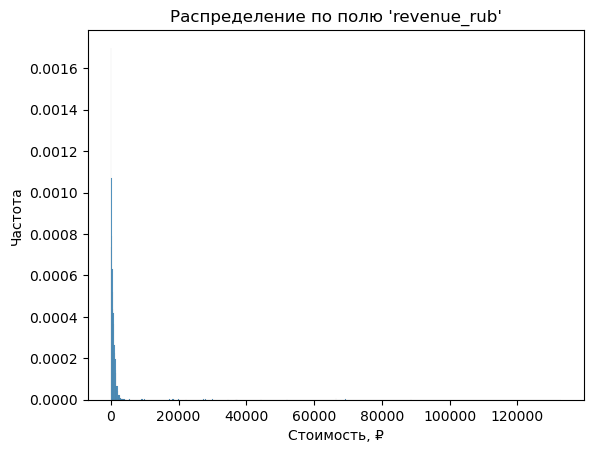

In [27]:
sns.histplot(data=df, x='revenue_rub', stat='density')

plt.title('Распределение по полю \'revenue_rub\'')
plt.xlabel('Стоимость, ₽')
plt.ylabel('Частота')

plt.show()

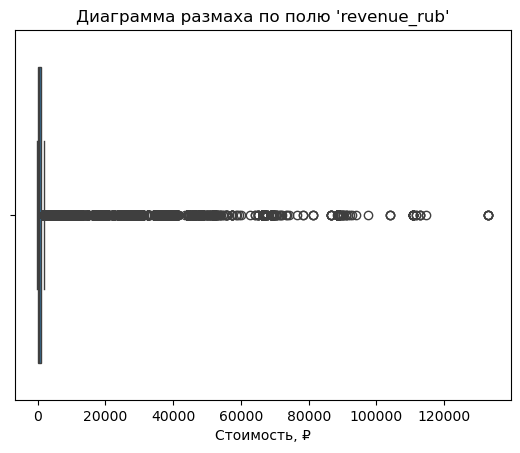

In [28]:
sns.boxplot(data=df, x='revenue_rub')

plt.title('Диаграмма размаха по полю \'revenue_rub\'')
plt.xlabel('Стоимость, ₽')
plt.ylabel('')

plt.show()

In [29]:
df['revenue_rub'].describe(percentiles=[.25, .5, .75, .95, .99])

count    290611.000000
mean        982.315796
std        4702.383006
min         -90.760000
25%         116.990000
50%         359.370000
75%         822.610000
95%        1803.140000
99%       18241.235273
max      133023.885631
Name: revenue_rub, dtype: float64

Видим, что распределение сильно скошено влево. Кроме того, есть мероприятия, на которых клиентам доплатили за участие. От таких значений избавимся. Удалим и те, что выше $99$-го процентиля,  поскольку они плохо отражают ситуацию на рынке.

In [30]:
print(f"Имеется {df.loc[df['revenue_rub'] < 0].shape[0]} заказов с отрицательной выручкой")

Имеется 381 заказов с отрицательной выручкой


In [31]:
def drop_and_report(df, condition, verbose=True):
    before = df.shape[0]
    new_df = df.loc[condition]
    after = new_df.shape[0]

    if verbose:
        print(f"Отбросили {before - after} строк, что есть {round( (before - after) / before * 100, 2 )}% всех данных")

    return new_df

In [32]:
df = drop_and_report(
    df,
    (df['revenue_rub'] > 0) & (df['revenue_rub'] < df['revenue_rub'].quantile(.99))
)

Отбросили 8816 строк, что есть 3.03% всех данных


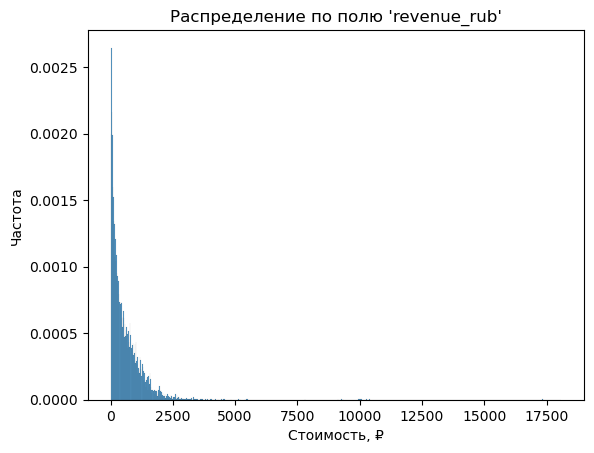

In [33]:
sns.histplot(data=df, x='revenue_rub', stat='density')

plt.title('Распределение по полю \'revenue_rub\'')
plt.xlabel('Стоимость, ₽')
plt.ylabel('Частота')

plt.show()

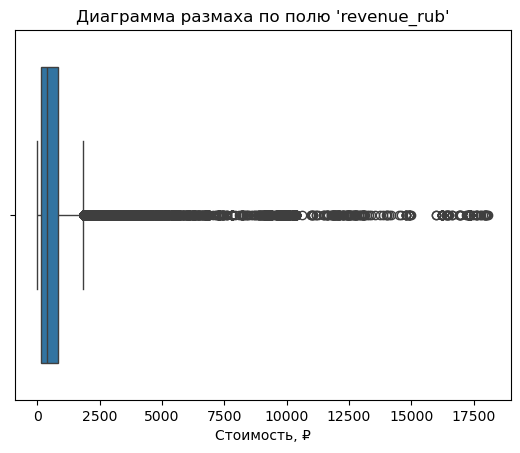

In [34]:
sns.boxplot(data=df, x='revenue_rub')

plt.title('Диаграмма размаха по полю \'revenue_rub\'')
plt.xlabel('Стоимость, ₽')
plt.ylabel('')

plt.show()

##### Обработка поля `tickets_count`

Теперь займёмся полем `tickets_count`.

In [35]:
df['tickets_count'].value_counts()

tickets_count
3     89202
2     80969
4     53265
1     40657
5     13281
6      4239
7        62
9        38
8        21
10       19
11       13
13        7
14        4
12        4
17        4
19        4
15        2
27        2
47        1
37        1
Name: count, dtype: int64

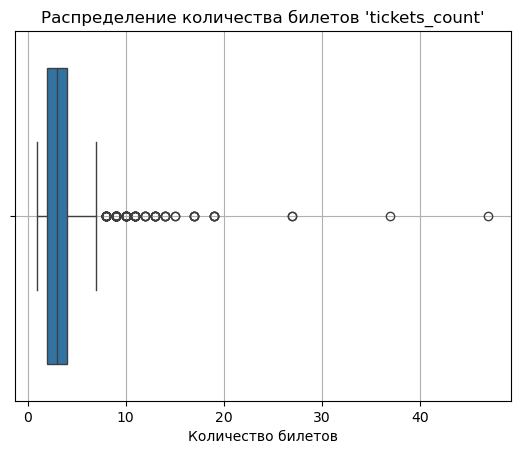

In [36]:
sns.boxplot(
    data=df,
    x='tickets_count',
)

plt.title('Распределение количества билетов \'tickets_count\'')
plt.xlabel('Количество билетов')

plt.grid('y')

plt.show()

In [37]:
q1 = df['tickets_count'].quantile(.25)
q3 = df['tickets_count'].quantile(.75)
iqr = q3 - q1
right_whisker = q3 + 1.5 * iqr

outliers_info = df.loc[df['tickets_count'] > right_whisker]
outliers_amount = outliers_info.shape[0]
print(f"За пределами ящика с усами лежит {outliers_amount} значений")

За пределами ящика с усами лежит 120 значений


In [38]:
right_whisker

np.float64(7.0)

In [39]:
outliers_info.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,revenue_rub
1137,019fa401ddb00aa,mobile,4486939,2024-09-13,2024-09-13 12:19:52,rub,1260.62,10,1.0,562954,b6a34397-5581-4d0d-8ee7-62e9852ac06c,концерты,билеты_без_проблем,североярская_область,озёрск,1260.62
2846,0263f0dddb290b6,mobile,1692296,2024-10-21,2024-10-21 22:40:19,rub,1231.70,9,NaN,586844,0aeb1f89-dfc3-4171-bfaa-e1960df7f37a,другое,мой_билет,североярская_область,озёрск,1231.70
18847,0beb8fc0c0a9ce1,mobile,8196880,2024-08-28,2024-08-28 22:20:12,rub,749.28,9,0.0,555072,ce448a71-45ad-4254-8292-062bdea65755,другое,билеты_без_проблем,североярская_область,озёрск,749.28
19421,0beb8fc0c0a9ce1,mobile,6891329,2024-09-06,2024-09-06 19:01:36,rub,531.80,9,0.0,413693,025775e3-1748-41ed-8b79-eccba45bc410,другое,билеты_без_проблем,каменноярский_край,лесоярово,531.80
22166,0beb8fc0c0a9ce1,desktop,7486989,2024-10-07,2024-10-07 14:26:49,rub,1128.47,9,0.0,529629,30e84abc-b350-4a7d-a54b-5943680b54b0,другое,билеты_без_проблем,североярская_область,озёрск,1128.47


##### Обработка поля `days_since_prev`

Наконец, займёмся полем `days_since_prev`. Пропускам в этом поле соответствуют пользователи, совершившие одну покупку за всё время. Имея это в виду, заполним их числом $-1$ и преобразуем к целочисленному виду:

In [40]:
df.loc[:, 'days_since_prev'] = df['days_since_prev'].fillna(-1)
df['days_since_prev'] = pd.to_numeric(df['days_since_prev'], downcast='integer')

df.info()

<class 'pandas.DataFrame'>
Index: 281795 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                281795 non-null  str           
 1   device_type_canonical  281795 non-null  category      
 2   order_id               281795 non-null  int64         
 3   order_dt               281795 non-null  datetime64[us]
 4   order_ts               281795 non-null  datetime64[us]
 5   currency_code          281795 non-null  category      
 6   revenue                281795 non-null  float64       
 7   tickets_count          281795 non-null  int8          
 8   days_since_prev        281795 non-null  int16         
 9   event_id               281795 non-null  int64         
 10  event_name             281795 non-null  category      
 11  event_type_main        281795 non-null  category      
 12  service_name           281795 non-null  category      
 13  

Готово 👌

#### Промежуточный вывод

На этапе предобработки данных были выполнены следуюшие действия:
- вся выручка была приведена к единой валюте, российскому рублю. Для этого был создан столбец `revenue_rub`, содержащий выручку в рублях;
- поля `service_name`, `region_name`, `city_name` были нормализованы, после чего поля `device_type_canonical`, `currency_code`, `event_type_main`, `service_name`, `region_name`, `city_name` и `event_name` были приведены к категориальному типу данных;
- числовые поля `tickets_count`, `revenue` и `revenue_rub` были оптимизированы в памяти;
- по полю `revenue_rub` были обнаружены выбросы, в связи с чем были отброшены значения, большие $99$-го процентиля. Потери составили $8816$ строк, что есть $3.03\%$ всех данных;
- пропуски в поле `days_since_prev` были заменены на значение-заглушку $-1$ и приведены к целочисленному типу.

---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [41]:
df = df.sort_values(by=['user_id', 'order_ts'])

In [42]:
df_agged = df.groupby('user_id')[[
    'order_dt', 
    'device_type_canonical',
    'region_name',
    'service_name', 
    'event_type_main',
    'order_id',
    'revenue_rub',
    'tickets_count',
    'days_since_prev'
]].agg({
    'order_dt': ['first', 'last'],
    'device_type_canonical': 'first',
    'region_name': 'first',
    'service_name': 'first',
    'event_type_main': 'first',
    'order_id': 'count',
    'revenue_rub': 'mean',
    'tickets_count': 'mean',
    'days_since_prev': 'mean'
})

df_agged.head()

order_dt            device_type_canonical  \
                     first       last                 first   
user_id                                                       
0002849b70a3ce2 2024-08-20 2024-08-20                mobile   
0005ca5e93f2cf4 2024-07-23 2024-10-06                mobile   
000898990054619 2024-07-13 2024-10-23                mobile   
00096d1f542ab2b 2024-08-15 2024-08-15               desktop   
000a55a418c128c 2024-09-29 2024-10-15                mobile   

                          region_name   service_name event_type_main order_id  \
                                first          first           first    count   
user_id                                                                         
0002849b70a3ce2    каменевский_регион   край_билетов           театр        1   
0005ca5e93f2cf4    каменевский_регион      мой_билет        выставки        2   
000898990054619  североярская_область    лови_билет!          другое        3   
00096d1f542ab2b    каменевский_регион   край_билетов           театр        1   
000a55a418c128c      поленовский_край  лучшие_билеты           театр        2   

                 revenue_rub tickets_count days_since_prev  
                        mean          mean            mean  
user_id                                                     
0002849b70a3ce2  1521.940000      4.000000       -1.000000  
0005ca5e93f2cf4   774.010000      3.000000       37.000000  
000898990054619   767.213333      2.666667       33.666667  
00096d1f542ab2b   917.830000      4.000000       -1.000000  
000a55a418c128c    61.310000      1.500000        7.500000

In [43]:
df_agged.shape

(21564, 10)

In [44]:
df_agged.describe()

order_dt                                  order_id  \
                            first                        last         count   
count                       21564                       21564  21564.000000   
mean   2024-08-10 22:08:24.841402  2024-09-19 03:35:09.515859     13.067845   
min           2024-06-01 00:00:00         2024-06-01 00:00:00      1.000000   
25%           2024-06-26 00:00:00         2024-08-27 00:00:00      1.000000   
50%           2024-08-10 00:00:00         2024-10-04 00:00:00      2.000000   
75%           2024-09-23 00:00:00         2024-10-23 00:00:00      5.000000   
max           2024-10-31 00:00:00         2024-10-31 00:00:00  10014.000000   
std                           NaN                         NaN    120.440261   

        revenue_rub tickets_count days_since_prev  
               mean          mean            mean  
count  21564.000000  21564.000000    21564.000000  
mean     655.811671      2.755811        6.237661  
min        0.070000      1.000000       -1.000000  
25%      231.055000      2.000000       -1.000000  
50%      496.795490      2.761905       -0.111111  
75%      814.969375      3.142857        9.419643  
max    18048.810281     12.000000      147.000000  
std      935.187218      0.927116       11.782084

Избавимся от двухэтажных названий колонок:

In [45]:
df_agged.columns = ['_'.join(col).strip() for col in df_agged.columns.values]

df_agged.head()

,order_dt_first,order_dt_last,device_type_canonical_first,region_name_first,service_name_first,event_type_main_first,order_id_count,revenue_rub_mean,tickets_count_mean,days_since_prev_mean
user_id,,,,,,,,,,
0002849b70a3ce2,2024-08-20,2024-08-20,mobile,каменевский_регион,край_билетов,театр,1,1521.940000,4.000000,-1.000000
0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,каменевский_регион,мой_билет,выставки,2,774.010000,3.000000,37.000000
000898990054619,2024-07-13,2024-10-23,mobile,североярская_область,лови_билет!,другое,3,767.213333,2.666667,33.666667
00096d1f542ab2b,2024-08-15,2024-08-15,desktop,каменевский_регион,край_билетов,театр,1,917.830000,4.000000,-1.000000
000a55a418c128c,2024-09-29,2024-10-15,mobile,поленовский_край,лучшие_билеты,театр,2,61.310000,1.500000,7.500000


In [46]:
df_agged['is_two'] = df_agged['order_id_count'] >= 2
df_agged['is_five'] = df_agged['order_id_count'] >= 5

df_agged.head()

,order_dt_first,order_dt_last,device_type_canonical_first,region_name_first,service_name_first,event_type_main_first,order_id_count,revenue_rub_mean,tickets_count_mean,days_since_prev_mean,is_two,is_five
user_id,,,,,,,,,,,,
0002849b70a3ce2,2024-08-20,2024-08-20,mobile,каменевский_регион,край_билетов,театр,1,1521.940000,4.000000,-1.000000,False,False
0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,каменевский_регион,мой_билет,выставки,2,774.010000,3.000000,37.000000,True,False
000898990054619,2024-07-13,2024-10-23,mobile,североярская_область,лови_билет!,другое,3,767.213333,2.666667,33.666667,True,False
00096d1f542ab2b,2024-08-15,2024-08-15,desktop,каменевский_регион,край_билетов,театр,1,917.830000,4.000000,-1.000000,False,False
000a55a418c128c,2024-09-29,2024-10-15,mobile,поленовский_край,лучшие_билеты,театр,2,61.310000,1.500000,7.500000,True,False


In [47]:
df_agged = df_agged.rename(columns={
    'order_id_count': 'orders_count'
})


---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [48]:
total_users = df_agged.shape[0]
avg_revenue_rub = df_agged['revenue_rub_mean'].mean()
is_two_ratio = df_agged['is_two'].mean()
is_five_ratio = df_agged['is_five'].mean()

print(f"Всего имеется {total_users} пользователей.")
print(f"В среднем с одного заказа удается выручить {avg_revenue_rub:.2f} ₽.")
print(f"Доля пользователей с 2+ заказами составляет {is_two_ratio * 100:.2f}%.")
print(f"Доля пользователей с 5+ заказами составляет {is_five_ratio * 100:.2f}%.")

Всего имеется 21564 пользователей.
В среднем с одного заказа удается выручить 655.81 ₽.
Доля пользователей с 2+ заказами составляет 61.74%.
Доля пользователей с 5+ заказами составляет 29.00%.


In [49]:
df_agged[['orders_count', 'tickets_count_mean', 'days_since_prev_mean']].describe()

,orders_count,tickets_count_mean,days_since_prev_mean
count,21564.000000,21564.000000,21564.000000
mean,13.067845,2.755811,6.237661
std,120.440261,0.927116,11.782084
min,1.000000,1.000000,-1.000000
25%,1.000000,2.000000,-1.000000
50%,2.000000,2.761905,-0.111111
75%,5.000000,3.142857,9.419643
max,10014.000000,12.000000,147.000000


Видим, что в поле `orders_count` имеется число $10195$. Вряд ли пользователь за разумное время мог совершить такое количество заказов/

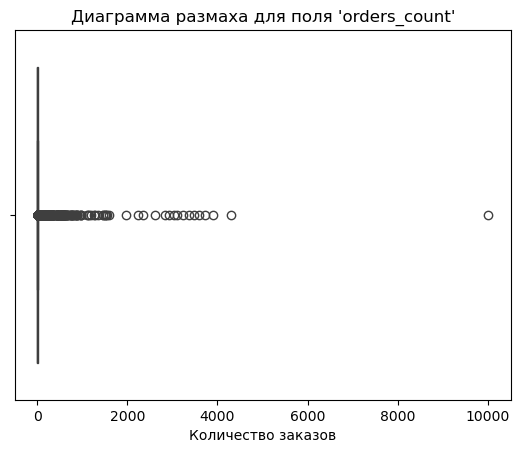

In [50]:
sns.boxplot(
    data=df_agged,
    x='orders_count'
)

plt.title('Диаграмма размаха для поля \'orders_count\'')
plt.xlabel('Количество заказов')

plt.show()

Посмотрим, сколько потратил данный пользователь:

In [51]:
rockefeller_id = df_agged['orders_count'].idxmax()
rockefeller_spent = df.loc[df['user_id'] == rockefeller_id]['revenue_rub'].sum()

print(f"Пользователь {rockefeller_id} потратил {rockefeller_spent:.0f} ₽ за всё время")

Пользователь 0beb8fc0c0a9ce1 потратил 5481790 ₽ за всё время


~Обидно терять такого клиента~ Кроме того, из диаграммы видно, что имеется большое количество выбросов за пределами усов ящика. Такие данные будут искажать средний профиль пользователя. поэтому избавимся от них — отсеим по $9*$-ому процентилю. Для этого выясним, чему равны $95$-йи $99$-й процентили:

In [52]:
print('95-й процентиль:', df_agged['orders_count'].quantile(.95))
print('99-й процентиль:', df_agged['orders_count'].quantile(.99))

95-й процентиль: 31.0
99-й процентиль: 152.0


In [53]:
x = df_agged.loc[df_agged['orders_count'] > df_agged['orders_count'].quantile(.95)].shape[0]
print(f"\
Всего {x} записей в поле 'orders_count' имеют значение выше 95-го процентиля. \
Это {x / df_agged.shape[0] * 100:.2}% всех данных")

y = df_agged.loc[df_agged['orders_count'] > df_agged['orders_count'].quantile(.99)].shape[0]
print(f"\
Всего {y} записей в поле 'orders_count' имеют значение выше 99-го процентиля. \
Это {y / df_agged.shape[0] * 100:.2}% всех данных")

Всего 1072 записей в поле 'orders_count' имеют значение выше 95-го процентиля. Это 5.0% всех данных
Всего 215 записей в поле 'orders_count' имеют значение выше 99-го процентиля. Это 1.0% всех данных


Видим, что $99$-й процентиль имеет не такое большое значение. К тому же, после фильтрации мы потеряем не более $1\%$ данных.

In [54]:
df_agged = drop_and_report(
    df_agged, 
    df_agged['orders_count'] < df_agged['orders_count'].quantile(.99)
)

print('Посмотрим, как изменились статистические составляющие таблицы:', 
     'Мода по указанным полям:', sep='\n\n', end='\n')
print(
    df_agged.loc[df_agged['orders_count'] > 1][['orders_count', 'tickets_count_mean', 'days_since_prev_mean']].mode(), 
    end='\n\n'
)
df_agged[['orders_count', 'tickets_count_mean', 'days_since_prev_mean']].describe()

Отбросили 217 строк, что есть 1.01% всех данных
Посмотрим, как изменились статистические составляющие таблицы:

Мода по указанным полям:
   orders_count  tickets_count_mean  days_since_prev_mean
0             2                 3.0                  -0.5



,orders_count,tickets_count_mean,days_since_prev_mean
count,21347.000000,21347.000000,21347.000000
mean,6.421277,2.755932,6.296422
std,13.995104,0.931658,11.827291
min,1.000000,1.000000,-1.000000
25%,1.000000,2.000000,-1.000000
50%,2.000000,2.765957,-0.166667
75%,5.000000,3.166667,9.500000
max,149.000000,12.000000,147.000000


Как видим по значению моды, чаще всего пользователи выполняют один или два заказа, при этом всё же тяготеют к совершению лишь одного заказа. Чаще всего приобратается три билета в среднем. Это может быть связано с тем, что пользователи предпочитают посещать мероприятия в кругу семьи.

Для `tickets_count_mean` бросается в глаза низкое стандартное отклонение, и низкая вариативность данных подтверждается значением третьего квартиля. Это говорит о том, что в среднем пользователи крайне часто приобратают число билетов, близкое к $3$.

Для большей наглядности изобразим указанные столбцы на графике:

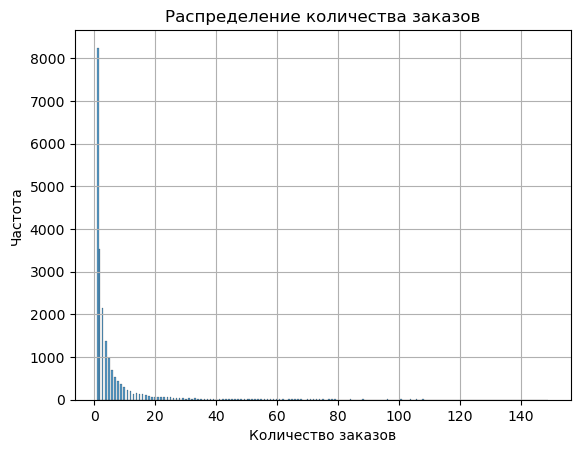

In [55]:
sns.histplot(
    data=df_agged,
    x='orders_count'
)

plt.title('Распределение количества заказов')
plt.xlabel('Количество заказов')
plt.ylabel('Частота')

plt.grid('x')

plt.show()

In [56]:
df_agged['orders_count'].value_counts().to_frame().join(
    df_agged['orders_count'].value_counts(normalize=True)
)

,count,proportion
orders_count,,
1,8251,0.386518
2,3540,0.165831
3,2152,0.100810
4,1368,0.064084
5,968,0.045346
...,...,...
102,1,0.000047
92,1,0.000047
107,1,0.000047


Видим, что доля пользователей с одним заказом составляет $38.7\%$, в то время как доля пользователей хотя бы с двумя заказами не превосходит и $17\%$.

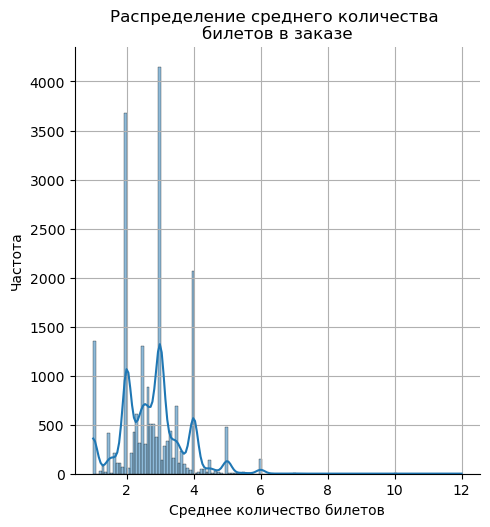

In [57]:
sns.displot(
    df_agged['tickets_count_mean'],
    kde=True
)

plt.title('Распределение среднего количества \nбилетов в заказе')
plt.xlabel('Среднее количество билетов')
plt.ylabel('Частота')

plt.grid('abracadabra')

plt.show()

Наконец, рассмотрим распределение по полю `days_since_prev_mean`. Так как чаще всего пользователи совершают одну покупку и покидают платформу, отделим их и на соседнем графике будем смотреть на распределение только тех пользователей, которые совершили более одной покупки.

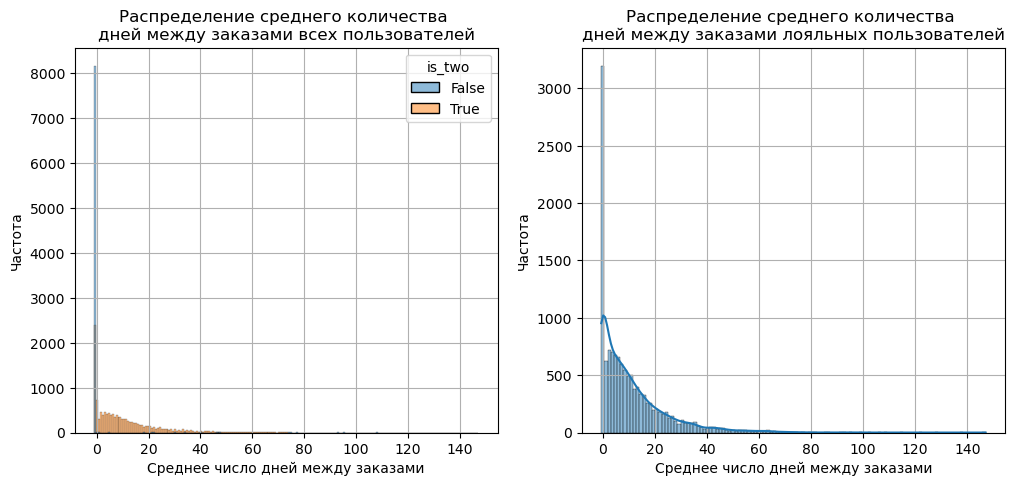

In [58]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(
    data=df_agged,
    x='days_since_prev_mean',
    ax=ax[0],
    hue='is_two'
)

sns.histplot(
    data=df_agged.loc[df_agged['days_since_prev_mean'] != -1],
    x='days_since_prev_mean',
    ax=ax[1],
    kde=True
)

ax[0].set_title('Распределение среднего количества \nдней между заказами всех пользователей')
ax[1].set_title('Распределение среднего количества \nдней между заказами лояльных пользователей')

ax[0].set_xlabel('Среднее число дней между заказами')
ax[1].set_xlabel('Среднее число дней между заказами')
ax[0].set_ylabel('Частота')
ax[1].set_ylabel('Частота')

ax[0].grid('x')
ax[1].grid('y')

plt.show()

#### Промежуточный вывод

По итогу данного шага были агрегированы данные по всем пользователям с целью составления профиля пользователя. Согласно полученным данным, количество пользователей, которые совершали покупку единожды ($8251$), преобладает более чем в два раза над количеством совершивших более одной покупки на платформе ($3556$). Чаще всего пользователи в среднем приобретают $3$ билета на мероприятие. В среднем пользователи совершают около $5$ заказов на платформе с интервалами в $\approx 6$ дней.

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [59]:
df_agged.head()

,order_dt_first,order_dt_last,device_type_canonical_first,region_name_first,service_name_first,event_type_main_first,orders_count,revenue_rub_mean,tickets_count_mean,days_since_prev_mean,is_two,is_five
user_id,,,,,,,,,,,,
0002849b70a3ce2,2024-08-20,2024-08-20,mobile,каменевский_регион,край_билетов,театр,1,1521.940000,4.000000,-1.000000,False,False
0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,каменевский_регион,мой_билет,выставки,2,774.010000,3.000000,37.000000,True,False
000898990054619,2024-07-13,2024-10-23,mobile,североярская_область,лови_билет!,другое,3,767.213333,2.666667,33.666667,True,False
00096d1f542ab2b,2024-08-15,2024-08-15,desktop,каменевский_регион,край_билетов,театр,1,917.830000,4.000000,-1.000000,False,False
000a55a418c128c,2024-09-29,2024-10-15,mobile,поленовский_край,лучшие_билеты,театр,2,61.310000,1.500000,7.500000,True,False


In [60]:
def show_group_counts(col: pd.Series) -> pd.DataFrame:
    """
    Считает количество строк по категориям и их доли
    """
    counts = col.value_counts()
    percentages = (col.value_counts(normalize=True) * 100).round(2).astype(str) + '%'

    col_info = pd.concat([counts, percentages], axis=1, keys=['Количество заказов', 'Доля заказов'])
    return col_info

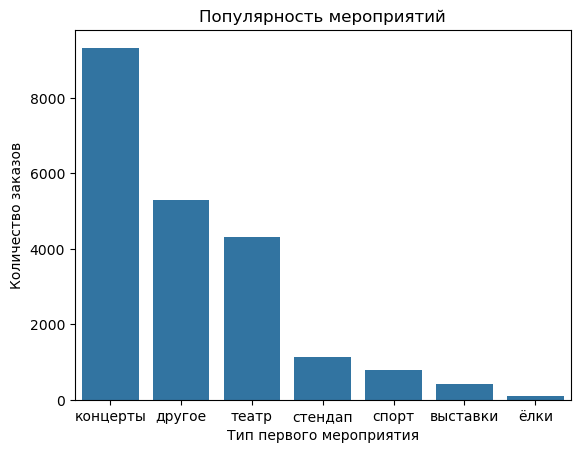

In [61]:
event_first = show_group_counts(df_agged['event_type_main_first'])
event_first = event_first.sort_values(by='Количество заказов', ascending=False)

sns.barplot(
    data=event_first,
    x='event_type_main_first',
    y='Количество заказов',
    order=event_first.index
)

plt.title('Популярность мероприятий')
plt.xlabel('Тип первого мероприятия')
plt.ylabel('Количество заказов')

plt.show()

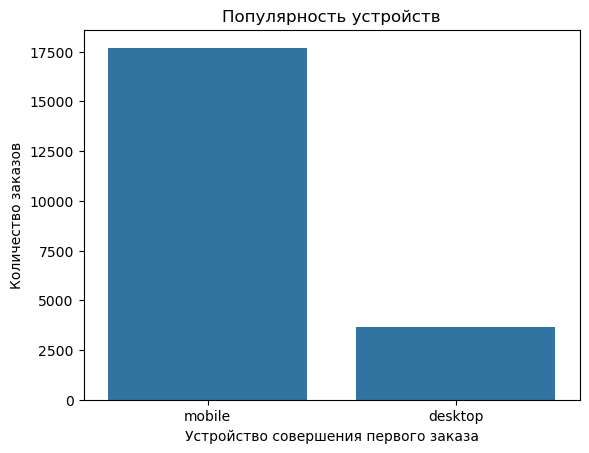

In [62]:
device_first = show_group_counts(df_agged['device_type_canonical_first'])
device_first = device_first.sort_values(by='Количество заказов', ascending=False)

sns.barplot(
    data=device_first,
    x='device_type_canonical_first',
    y='Количество заказов',
    order=device_first.index
)

plt.title('Популярность устройств')
plt.xlabel('Устройство совершения первого заказа')
plt.ylabel('Количество заказов')

plt.show()

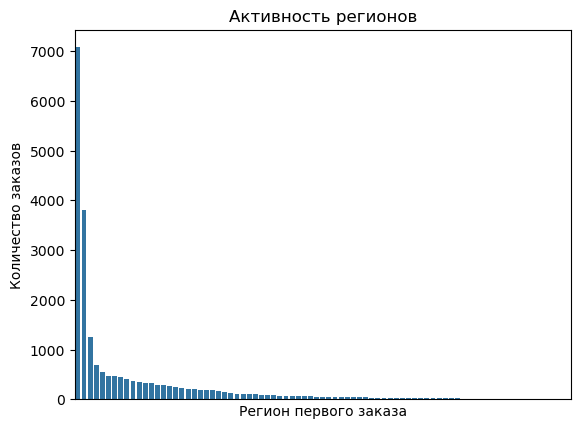

In [63]:
region_first = show_group_counts(df_agged['region_name_first'])
region_first = region_first.sort_values(by='Количество заказов', ascending=False)

sns.barplot(
    data=region_first,
    x='region_name_first',
    y='Количество заказов',
    order=region_first.index
)

plt.xticks([])

plt.title('Активность регионов')
plt.xlabel('Регион первого заказа')
plt.ylabel('Количество заказов')

plt.show()

In [64]:
n = 3
print(f"Топ {n} региона по количеству заказов: {', '.join(region_first.index.to_list()[:n])}.")

Топ 3 региона по количеству заказов: каменевский_регион, североярская_область, широковская_область.


In [65]:
region_first.head(n)

,Количество заказов,Доля заказов
region_name_first,,
каменевский_регион,7074,33.14%
североярская_область,3817,17.88%
широковская_область,1251,5.86%


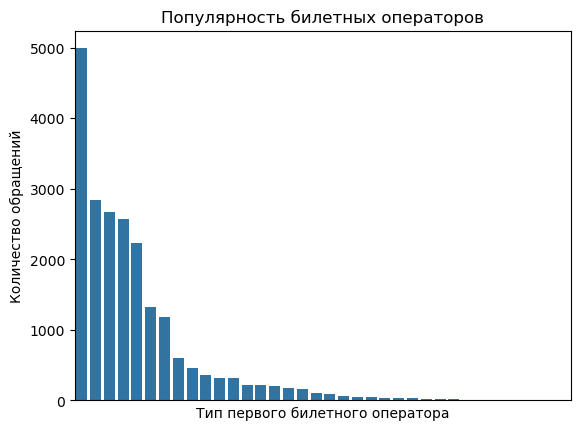

In [66]:
service_first = show_group_counts(df_agged['service_name_first'])
service_first = service_first.sort_values(by='Количество заказов', ascending=False)

sns.barplot(
    data=service_first,
    x='service_name_first',
    y='Количество заказов',
    order=service_first.index
)

plt.xticks([])

plt.title('Популярность билетных операторов')
plt.xlabel('Тип первого билетного оператора')
plt.ylabel('Количество обращений')

plt.show()

In [67]:
n = 5
print(f"Топ {n} операторов по количеству заказов: {', '.join(service_first.index.to_list()[:n])}.")

Топ 5 операторов по количеству заказов: билеты_без_проблем, лови_билет!, мой_билет, билеты_в_руки, облачко.


In [68]:
service_first.head(n)

,Количество заказов,Доля заказов
service_name_first,,
билеты_без_проблем,4991,23.38%
лови_билет!,2835,13.28%
мой_билет,2675,12.53%
билеты_в_руки,2565,12.02%
облачко,2225,10.42%


Видим, что все данные имеют скошенное распределение. Конкретнее:
- концерты посещают в качестве первого мероприятия чаще
- заказы предпочитают совершать с мобильных устройств
- чаще всего (и это сильно заметно) первый заказ совершают в Каменевском регионе
- в качестве первого билетного оператора выбирают "Билеты без проблем"

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


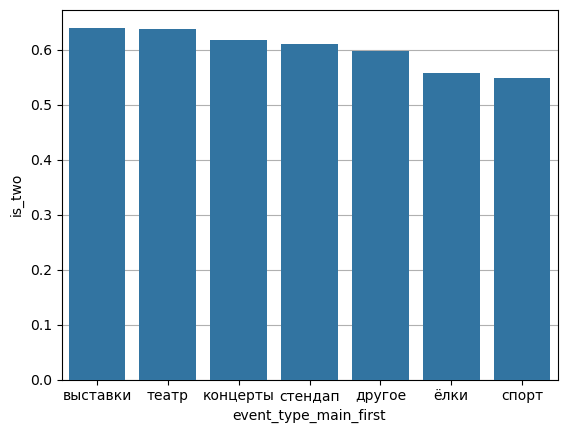

In [69]:
event_first_is_two_mean = df_agged.groupby('event_type_main_first')['is_two'].mean()
event_first_is_two_mean = event_first_is_two_mean.sort_values(ascending=False).reset_index()

plt.grid('x', zorder=-1)

sns.barplot(
    data=event_first_is_two_mean,
    x='event_type_main_first',
    y='is_two',
    order=event_first_is_two_mean['event_type_main_first'],
    zorder=3
)



plt.show()

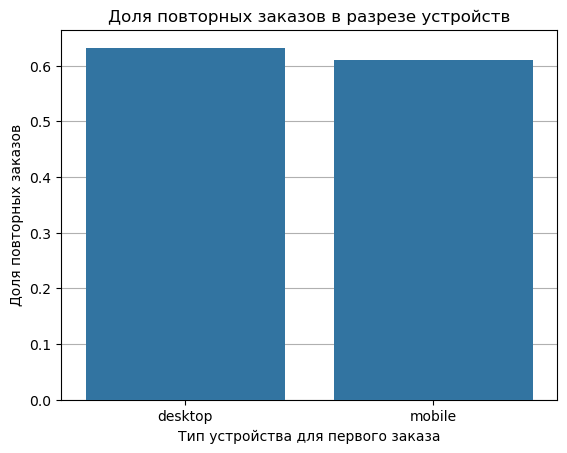

In [70]:
device_first_is_two_mean = df_agged.groupby('device_type_canonical_first')['is_two'].mean()
device_first_is_two_mean = device_first_is_two_mean.sort_values(ascending=False).reset_index()

plt.grid('x', zorder=-1)

sns.barplot(
    data=device_first_is_two_mean,
    x='device_type_canonical_first',
    y='is_two',
    order=device_first_is_two_mean['device_type_canonical_first'],
    zorder=3
)

plt.title('Доля повторных заказов в разрезе устройств')
plt.xlabel('Тип устройства для первого заказа')
plt.ylabel('Доля повторных заказов')

plt.show()

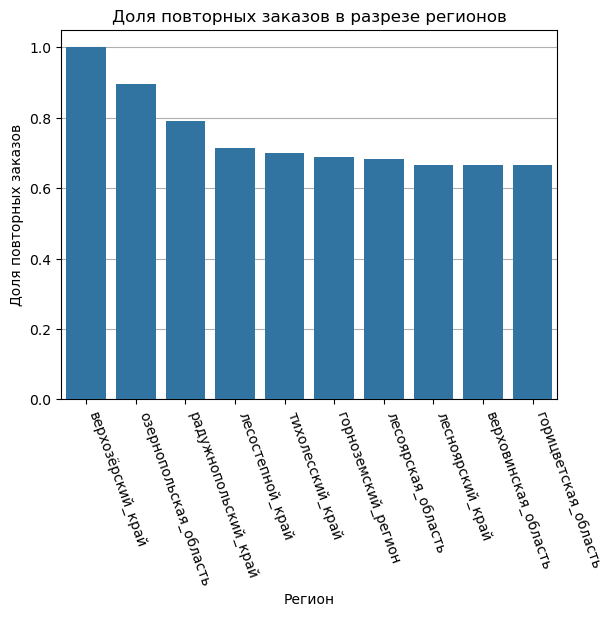

In [71]:
region_first_is_two_mean = df_agged.groupby('region_name_first')['is_two'].mean().reset_index()
region_first_is_two_mean_constrained = region_first_is_two_mean.sort_values(by='is_two', ascending=False)[:10]

plt.grid('x', zorder=-1)

sns.barplot(
    data=region_first_is_two_mean_constrained,
    x='region_name_first',
    y='is_two',
    order=region_first_is_two_mean_constrained['region_name_first'],
    zorder=3
)

plt.xticks(rotation=-70, ha='left')

plt.title('Доля повторных заказов в разрезе регионов')
plt.xlabel('Регион')
plt.ylabel('Доля повторных заказов')

plt.show()

In [72]:
region_order_counts = df_agged['region_name_first'].value_counts()
region_first_is_two_mean['Количество заказов'] = region_first_is_two_mean.apply(
    lambda x: region_order_counts[x['region_name_first']],
    axis=1
)

In [73]:
region_first_is_two_mean.describe()

,is_two,Количество заказов
count,81.000000,81.000000
mean,0.558636,263.543210
std,0.144390,889.987206
min,0.000000,1.000000
25%,0.500000,22.000000
50%,0.580952,50.000000
75%,0.636364,197.000000
max,1.000000,7074.000000


In [74]:
most_active_regions = region_first_is_two_mean.loc[
    (region_first_is_two_mean['Количество заказов'] > region_first_is_two_mean['Количество заказов'].quantile(.25)) & 
    (region_first_is_two_mean['is_two'] > region_first_is_two_mean['is_two'].mean())
].sort_values(by='is_two', ascending=False)

most_active_regions.head(10)

,region_name_first,is_two,Количество заказов
46,озернопольская_область,0.896552,29
51,радужнопольский_край,0.791667,24
36,лесостепной_край,0.714286,63
12,горноземский_регион,0.689655,29
11,горицветская_область,0.665339,251
57,светополянский_округ,0.665272,478
79,ягодиновская_область,0.661538,65
2,берёзовская_область,0.657407,108
54,речицкий_регион,0.656085,189
77,широковская_область,0.649081,1251


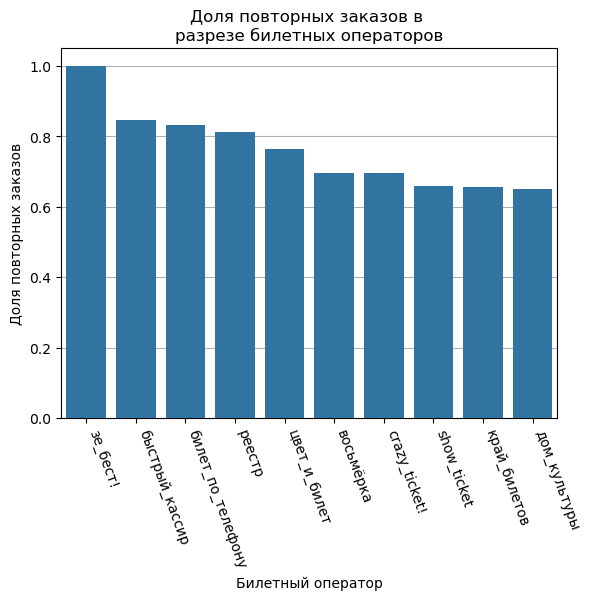

In [75]:
service_first_is_two_mean = df_agged.groupby('service_name_first')['is_two'].mean()
service_first_is_two_mean_constrained = service_first_is_two_mean.sort_values(ascending=False).reset_index()[:10]

plt.grid('x', zorder=-1)

sns.barplot(
    data=service_first_is_two_mean_constrained,
    x='service_name_first',
    y='is_two',
    order=service_first_is_two_mean_constrained['service_name_first'],
    zorder=3
)

plt.xticks(rotation=-70, ha='left')

plt.title('Доля повторных заказов в \nразрезе билетных операторов')
plt.xlabel('Билетный оператор')
plt.ylabel('Доля повторных заказов')

plt.show()

In [76]:
df_agged.loc[df_agged['service_name_first'] == 'зе_бест!'].shape[0]

1

Все клиенты оператора "Зэ бест!" совершили более одного заказа. Клинтов — один.

In [77]:
service_popularity = pd.merge(
    service_first_is_two_mean,
    df_agged['service_name_first'].value_counts(), 
    left_index=True, 
    right_index=True
)

service_popularity.columns = ['Доля возвратов', 'Количество заказов']

service_popularity['Доля заказов, %'] = service_popularity['Количество заказов'] / \
    service_popularity['Количество заказов'].sum() * 100

service_popularity = service_popularity.sort_values(by='Доля возвратов', ascending=False)

service_popularity.loc[
    (service_popularity['Доля возвратов'] > service_popularity['Доля возвратов'].mean()) &
    (service_popularity['Количество заказов'] > service_popularity['Количество заказов'].quantile(.25))
]

,Доля возвратов,Количество заказов,"Доля заказов, %"
service_name_first,,,
быстрый_кассир,0.847458,59,0.276385
реестр,0.812500,32,0.149904
восьмёрка,0.696629,89,0.416920
crazy_ticket!,0.695652,46,0.215487
show_ticket,0.658824,170,0.796365
край_билетов,0.655172,464,2.173608
дом_культуры,0.650838,358,1.677051
мир_касс,0.644550,211,0.988429
росбилет,0.634615,52,0.243594


В коде выше мы оставили только тех операторов, у которых доля возвратов выше, а количество клиентов достаточно большое, чтобы делать о них содержательные выводы. А выводы такие:

- В среднем примерно в $60\%$ случаев пользователи, совершавшие первые заказ с любого из двух типов устройств, возвращаются
- в среднем около $60\%$ клиентов возвращаются после посещения любого мероприятия в разрезе его типа. Реже всего, в половине случаев, пользователи возвращаются после ёлок
- операторы "Быстрый кассир" и "Реестр" имеют долю клиентов с повторными заказами, на более чем на $10\%$ превышающую все остальные.

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

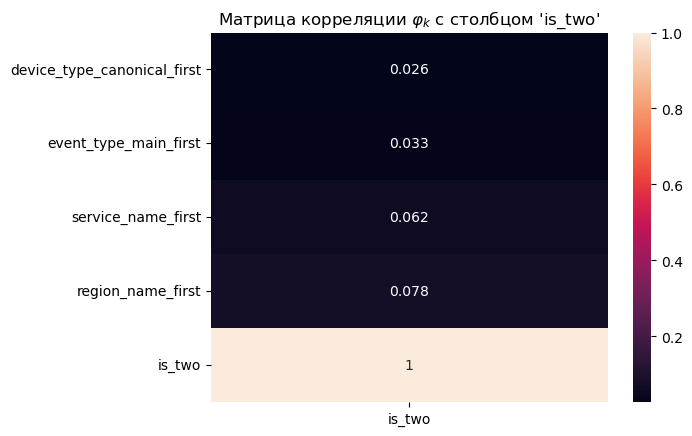

In [78]:
corr_matrix = phik_matrix(
    df_agged[[
        'event_type_main_first', 
        'device_type_canonical_first', 
        'region_name_first', 
        'service_name_first', 
        'is_two'
    ]])['is_two']

corr_matrix = corr_matrix.sort_values()

sns.heatmap(
    data=pd.DataFrame(corr_matrix),
    annot=True
)

plt.title('Матрица корреляции $\\varphi_k$ с столбцом \'is_two\'')

plt.show()

Видим отсутствие корреляции между типом мероприятия и типом мероприятия. Конкретно для данного датасета, однако, можно обнаружить, что пользователи, которые совершили первый заказ на спортивные мероприятия, *реже* совершают повторный заказ, чем пользователи, оформившие свой первый заказ на концерты. Гипотеза 1 неверна.

In [79]:
region_first_is_two_mean.head()

,region_name_first,is_two,Количество заказов
0,белоярская_область,0.650000,20
1,берестовский_округ,0.636364,22
2,берёзовская_область,0.657407,108
3,боровлянский_край,0.520000,100
4,верховинская_область,0.666667,3


In [80]:
region_info = region_first.join(region_first_is_two_mean.set_index('region_name_first')['is_two'])
region_info['is_two'].describe()

count    81.000000
mean      0.558636
std       0.144390
min       0.000000
25%       0.500000
50%       0.580952
75%       0.636364
max       1.000000
Name: is_two, dtype: float64

In [81]:
most_active_regions

,region_name_first,is_two,Количество заказов
46,озернопольская_область,0.896552,29
51,радужнопольский_край,0.791667,24
36,лесостепной_край,0.714286,63
12,горноземский_регион,0.689655,29
11,горицветская_область,0.665339,251
57,светополянский_округ,0.665272,478
79,ягодиновская_область,0.661538,65
2,берёзовская_область,0.657407,108
54,речицкий_регион,0.656085,189
77,широковская_область,0.649081,1251


In [82]:
region_info.loc[region_info['Количество заказов'] > most_active_regions['Количество заказов'].mean()]

,Количество заказов,Доля заказов,is_two
region_name_first,,,
каменевский_регион,7074,33.14%,0.621431
североярская_область,3817,17.88%,0.643961
широковская_область,1251,5.86%,0.649081
озернинский_край,687,3.22%,0.551674
малиновоярский_округ,542,2.54%,0.564576


Однако выше в таблице `most_active_regions` мы видели, что есть регионы с не такой высокой активностью (до $100$ заказов в сумме), но более высокой возвращаемостью пользователей.

Итак, обе гипотезы оказались неверны.

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


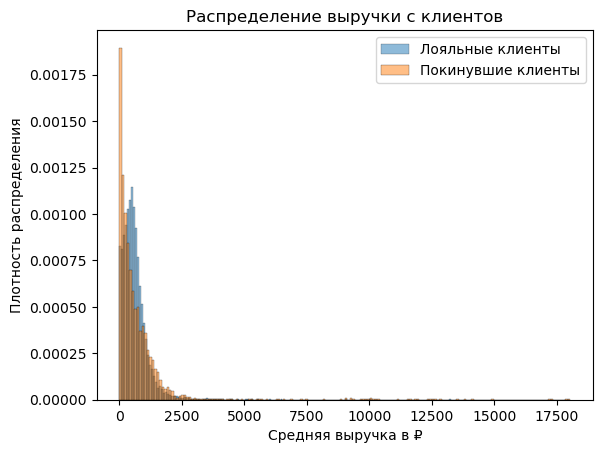

In [83]:
loyal = df_agged.loc[df_agged['is_two']]['revenue_rub_mean']
one_off = df_agged.loc[~df_agged['is_two']]['revenue_rub_mean']

sns.histplot(
    data=loyal,
    alpha=0.5,
    stat='density',
    label='Лояльные клиенты'
)

sns.histplot(
    data=one_off,
    alpha=0.5,
    stat='density',
    label='Покинувшие клиенты'
)

plt.legend()

plt.title('Распределение выручки с клиентов')
plt.xlabel('Средняя выручка в ₽')
plt.ylabel('Плотность распределения')

plt.show()

In [84]:
loyal.describe()

count    13096.000000
mean       639.796992
std        742.355941
min          0.352000
25%        291.910625
50%        523.898500
75%        798.549688
max      18006.092495
Name: revenue_rub_mean, dtype: float64

In [85]:
one_off.describe()

count     8251.000000
mean       683.604309
std       1187.096374
min          0.070000
25%        151.460000
50%        410.710000
75%        879.000000
max      18048.810281
Name: revenue_rub_mean, dtype: float64

In [86]:
print(f"Средняя выручка лояльных клиентов концентрируется вокруг {loyal.mode()[0]:.2f} ₽")
print(f"Средняя выручка одноразовых клиентов концентрируется вокруг {one_off.mode()[0]:.2f} ₽")

Средняя выручка лояльных клиентов концентрируется вокруг 1380.57 ₽
Средняя выручка одноразовых клиентов концентрируется вокруг 31.58 ₽


Видим, что мода средней выручки с лояльных пользователей смещена вправо по сравнению с нелояльными. Это подтверждает предположение о том, что лояльные клиенты склонны приобратать более дорогие билеты.

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


In [87]:
loyal_clients = df_agged.loc[df_agged['is_two'] & ~df_agged['is_five']]
super_loyal_clients = df_agged.loc[df_agged['is_five']]

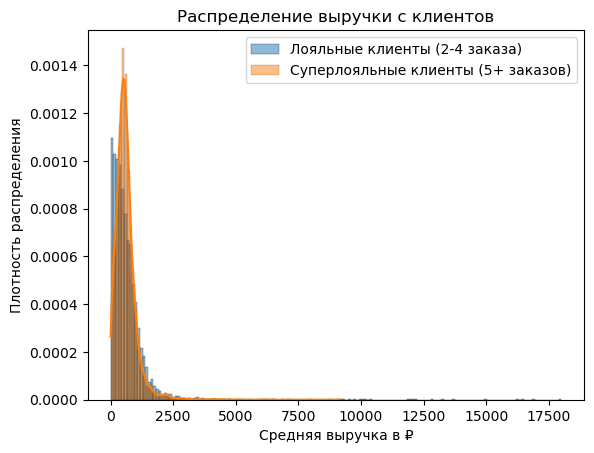

In [88]:
sns.histplot(
    data=loyal_clients['revenue_rub_mean'],
    alpha=0.5,
    stat='density',
    label='Лояльные клиенты (2-4 заказа)'
)

sns.histplot(
    data=super_loyal_clients['revenue_rub_mean'],
    alpha=0.5,
    stat='density',
    label='Суперлояльные клиенты (5+ заказов)',
    kde=True
)

plt.legend()

plt.title('Распределение выручки с клиентов')
plt.xlabel('Средняя выручка в ₽')
plt.ylabel('Плотность распределения')

plt.show()

In [89]:
print('2-4 заказа. Среднее = %.2f' % loyal_clients['revenue_rub_mean'].mean())
print('5+ заказов. Среднее = %.2f' % super_loyal_clients['revenue_rub_mean'].mean())

2-4 заказа. Среднее = 665.25
5+ заказов. Среднее = 610.02


In [90]:
print(f"Средняя выручка лояльных клиентов концентрируется вокруг {loyal_clients['revenue_rub_mean'].mode()[0]:.2f} ₽")
print(f"Средняя выручка одноразовых клиентов концентрируется вокруг {super_loyal_clients['revenue_rub_mean'].mode()[0]:.2f} ₽")

Средняя выручка лояльных клиентов концентрируется вокруг 1380.57 ₽
Средняя выручка одноразовых клиентов концентрируется вокруг 28.61 ₽


In [91]:
super_loyal_clients['revenue_rub_mean'].mode()

0     28.610000
1    247.551667
2    990.560000
Name: revenue_rub_mean, dtype: float64

Видим, что хвост распределения клиентов с $2$—$4$ заказами жирнее. От этого среднее смещено правее. Однако клиенты с 5 и более заказами чаще приобретают на более дорогие суммы.

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

In [92]:
df_agged.head()

,order_dt_first,order_dt_last,device_type_canonical_first,region_name_first,service_name_first,event_type_main_first,orders_count,revenue_rub_mean,tickets_count_mean,days_since_prev_mean,is_two,is_five
user_id,,,,,,,,,,,,
0002849b70a3ce2,2024-08-20,2024-08-20,mobile,каменевский_регион,край_билетов,театр,1,1521.940000,4.000000,-1.000000,False,False
0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,каменевский_регион,мой_билет,выставки,2,774.010000,3.000000,37.000000,True,False
000898990054619,2024-07-13,2024-10-23,mobile,североярская_область,лови_билет!,другое,3,767.213333,2.666667,33.666667,True,False
00096d1f542ab2b,2024-08-15,2024-08-15,desktop,каменевский_регион,край_билетов,театр,1,917.830000,4.000000,-1.000000,False,False
000a55a418c128c,2024-09-29,2024-10-15,mobile,поленовский_край,лучшие_билеты,театр,2,61.310000,1.500000,7.500000,True,False


In [93]:
bins = [1, 2, 3, 5, np.inf]
labels = ['1-2', '2-3', '3-5', '5+']

df_agged['tickets_count_segment'] = pd.cut(
    df_agged['tickets_count_mean'], 
    bins=bins,
    labels=labels
)

df_agged['tickets_count_segment'] = df_agged['tickets_count_segment'].astype('category')

df_agged.head()

,order_dt_first,order_dt_last,device_type_canonical_first,region_name_first,service_name_first,event_type_main_first,orders_count,revenue_rub_mean,tickets_count_mean,days_since_prev_mean,is_two,is_five,tickets_count_segment
user_id,,,,,,,,,,,,,
0002849b70a3ce2,2024-08-20,2024-08-20,mobile,каменевский_регион,край_билетов,театр,1,1521.940000,4.000000,-1.000000,False,False,3-5
0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,каменевский_регион,мой_билет,выставки,2,774.010000,3.000000,37.000000,True,False,2-3
000898990054619,2024-07-13,2024-10-23,mobile,североярская_область,лови_билет!,другое,3,767.213333,2.666667,33.666667,True,False,2-3
00096d1f542ab2b,2024-08-15,2024-08-15,desktop,каменевский_регион,край_билетов,театр,1,917.830000,4.000000,-1.000000,False,False,3-5
000a55a418c128c,2024-09-29,2024-10-15,mobile,поленовский_край,лучшие_билеты,театр,2,61.310000,1.500000,7.500000,True,False,1-2


<Axes: xlabel='tickets_count_mean', ylabel='Count'>

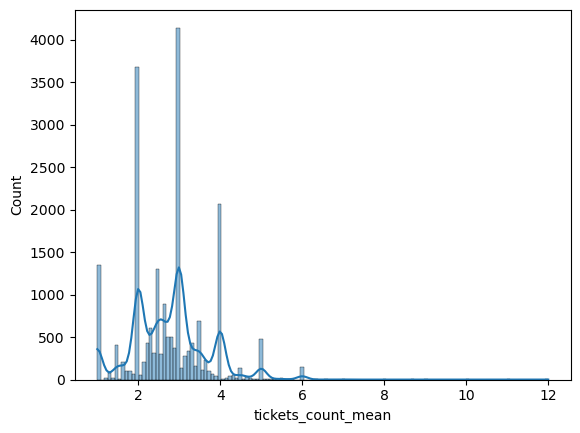

In [94]:
sns.histplot(
    data=df_agged,
    x='tickets_count_mean',
    kde=True,
)

Видим, что распределение среднего количества билетов мультимодальное. Попробуем выделить категории:

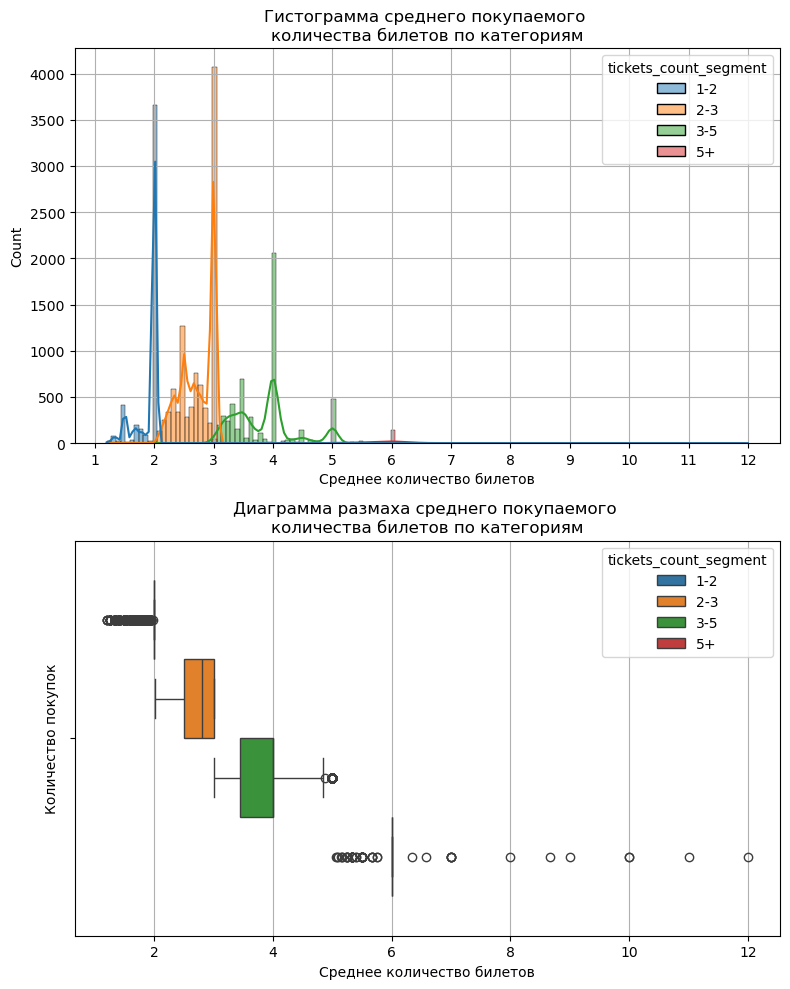

In [95]:
fig, ax = plt.subplots(2, 1, figsize=(8, 10))

ax[0].grid('x')
ax[0].set_xticks(range(13))

sns.histplot(
    data=df_agged,
    x='tickets_count_mean',
    ax=ax[0],
    kde=True,
    hue='tickets_count_segment'
)

ax[1].grid('y')

sns.boxplot(
    data=df_agged,
    x='tickets_count_mean',
    orient='y',
    ax=ax[1],
    hue='tickets_count_segment'
)

ax[0].set_title('Гистограмма среднего покупаемого \nколичества билетов по категориям')
ax[1].set_title('Диаграмма размаха среднего покупаемого \nколичества билетов по категориям')

ax[0].set_xlabel('Среднее количество билетов')
ax[1].set_ylabel('Количество покупок')
ax[1].set_xlabel('Среднее количество билетов')

plt.tight_layout()

plt.show()

In [96]:
tickets_segments_df = df_agged.reset_index().groupby('tickets_count_segment').agg({
    'user_id': 'count',
    'is_two': 'mean'
})

tickets_segments_df.columns = ['Число пользователей', 'Доля совершивших повторный заказ']

tickets_segments_df

,Число пользователей,Доля совершивших повторный заказ
tickets_count_segment,,
1-2,4709,0.477596
2-3,9630,0.743198
3-5,5449,0.633694
5+,209,0.325359


In [97]:
tickets_segments_df.corr()

,Число пользователей,Доля совершивших повторный заказ
Число пользователей,1.000000,0.960434
Доля совершивших повторный заказ,0.960434,1.000000


Распределение клиентов по сегментов явно неравномерное: пользователи в среднем чаще всего покупают от $2$ до $3$ билетов ($9719$) и реже всего — более $4$ билетов (всего $209$). Кроме того, имеется сильная ($0.96$) линейная положительная зависимость между числом пользователей в категории и долей тех из них, которые совершали повторную покупку. Это говорит о том, что обычно те, кто приобретает умеренное количество билетов, с большей вероятностью вернутся на платформу.

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [98]:
df_agged.head()

,order_dt_first,order_dt_last,device_type_canonical_first,region_name_first,service_name_first,event_type_main_first,orders_count,revenue_rub_mean,tickets_count_mean,days_since_prev_mean,is_two,is_five,tickets_count_segment
user_id,,,,,,,,,,,,,
0002849b70a3ce2,2024-08-20,2024-08-20,mobile,каменевский_регион,край_билетов,театр,1,1521.940000,4.000000,-1.000000,False,False,3-5
0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,каменевский_регион,мой_билет,выставки,2,774.010000,3.000000,37.000000,True,False,2-3
000898990054619,2024-07-13,2024-10-23,mobile,североярская_область,лови_билет!,другое,3,767.213333,2.666667,33.666667,True,False,2-3
00096d1f542ab2b,2024-08-15,2024-08-15,desktop,каменевский_регион,край_билетов,театр,1,917.830000,4.000000,-1.000000,False,False,3-5
000a55a418c128c,2024-09-29,2024-10-15,mobile,поленовский_край,лучшие_билеты,театр,2,61.310000,1.500000,7.500000,True,False,1-2


In [99]:
weekdays = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
df_agged['order_first_weekday'] = df_agged['order_dt_first'].apply(lambda x: weekdays[x.dayofweek])

df_agged['order_first_weekday'].head()

user_id
0002849b70a3ce2    Вт
0005ca5e93f2cf4    Вт
000898990054619    Сб
00096d1f542ab2b    Чт
000a55a418c128c    Вс
Name: order_first_weekday, dtype: str

In [100]:
weekdays_df = df_agged.reset_index().groupby('order_first_weekday')[['user_id', 'is_two']].agg({
    'user_id': 'count', 
    'is_two': 'mean'
})

weekdays_df.columns = ['Число пользователей', 'Доля совершивших повторный заказ']

weekdays_df

,Число пользователей,Доля совершивших повторный заказ
order_first_weekday,,
Вс,2767,0.604265
Вт,3071,0.614783
Пн,2834,0.625970
Пт,3253,0.601906
Сб,3294,0.628415
Ср,3022,0.619126
Чт,3106,0.599807


In [101]:
weekdays_df = weekdays_df.reset_index()

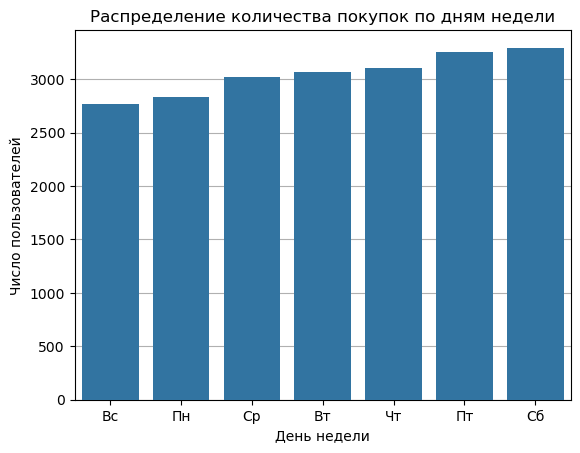

In [102]:
weekdays_df = weekdays_df.sort_values(by='Число пользователей')

plt.grid('y')

sns.barplot(
    data=weekdays_df,
    x='order_first_weekday',
    y='Число пользователей',
    order=weekdays_df['order_first_weekday'],
    zorder=3
)

plt.title('Распределение количества покупок по дням недели')
plt.xlabel('День недели')

plt.show()

Из диаграммы видно, что первый заказ чаще всего совершают по пятницам и субботам. Посмотрим, как день недели влияет на вероятность повторного заказа:

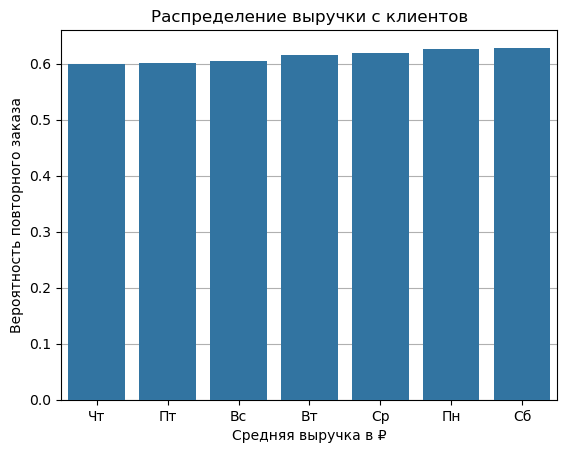

In [103]:
weekdays_df = weekdays_df.sort_values(by='Доля совершивших повторный заказ')

plt.grid('y')

sns.barplot(
    data=weekdays_df,
    x='order_first_weekday',
    y='Доля совершивших повторный заказ',
    order=weekdays_df['order_first_weekday'],
    zorder=3
)

plt.title('Распределение выручки с клиентов')
plt.xlabel('Средняя выручка в ₽')
plt.ylabel('Вероятность повторного заказа')

plt.show()

Никакой видимой взаимосвязи повторного заказа и дня недели совершения первого заказа не получается наблюдать. Проверим матрицу корреляции:

In [104]:
phik_matrix(df_agged[['order_first_weekday', 'is_two']])

,order_first_weekday,is_two
order_first_weekday,1.000000,0.013821
is_two,0.013821,1.000000


Значит, дата совершения первого заказа не влияет на совершение последующих.

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [105]:
loyal = df.loc[df['days_since_prev'] != -1]

loyal.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,revenue_rub
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,за_билетом!,каменевский_регион,глиногорск,1258.57
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,билеты_без_проблем,озернинский_край,родниковецк,1390.41
5,000898990054619,mobile,2613713,2024-10-23,2024-10-23 15:12:00,rub,902.74,3,19,500862,9cc55c15-4375-4129-9979-3129688ba1b4,концерты,облачко,лугоградская_область,кристалевск,902.74
8,000a55a418c128c,mobile,4657952,2024-10-15,2024-10-15 10:29:04,rub,74.84,2,16,271579,ddc795f8-7ef8-4eb0-b299-cb3e6ee24ba1,театр,лучшие_билеты,поленовский_край,дальнозолотск,74.84
15,000cf0659a9f40f,mobile,6818249,2024-06-20,2024-06-20 10:49:48,rub,710.95,2,0,516728,11be386f-7cb7-4aa1-a8e4-ba73a29c1af2,концерты,лови_билет!,широковская_область,радужнополье,710.95


In [106]:
mean_intervals = loyal.groupby('user_id')['days_since_prev'].mean()
intervals_and_second_orders = pd.merge(
    mean_intervals, 
    df_agged[['is_two', 'is_five']], 
    left_index=True, 
    right_index=True
)

intervals_and_second_orders = intervals_and_second_orders.rename({
    'days_since_prev': 'interval_mean'
}, axis=1)

intervals_and_second_orders

,interval_mean,is_two,is_five
user_id,,,
0005ca5e93f2cf4,75.000000,True,False
000898990054619,51.000000,True,False
000a55a418c128c,16.000000,True,False
000cf0659a9f40f,0.083333,True,True
00147c9209d45d3,0.000000,True,False
...,...,...,...
ffecf05f1f6a9c6,20.000000,True,False
ffed3ff067d4f12,26.000000,True,False
fff13b79bd47d7c,13.375000,True,True


In [107]:
group_one = intervals_and_second_orders.loc[
    intervals_and_second_orders['is_two'] & 
    ~intervals_and_second_orders['is_five']
]
group_two = intervals_and_second_orders.loc[
    intervals_and_second_orders['is_five']
]

print(f"В группе 2-4 заказов в среднем заказывают через {group_one['interval_mean'].mean():.2f} дней")
print(f"В группе 5+ заказов в среднем заказывают через {group_two['interval_mean'].mean():.2f} дней")

В группе 2-4 заказов в среднем заказывают через 21.35 дней
В группе 5+ заказов в среднем заказывают через 9.94 дней


In [108]:
21.41 / 9.95

2.1517587939698495

Пользователи, совершившие более $5$ покупок, совершают заказы чаще примерно в $2.15$ раз.

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [109]:
df_agged.head()

,order_dt_first,order_dt_last,device_type_canonical_first,region_name_first,service_name_first,event_type_main_first,orders_count,revenue_rub_mean,tickets_count_mean,days_since_prev_mean,is_two,is_five,tickets_count_segment,order_first_weekday
user_id,,,,,,,,,,,,,,
0002849b70a3ce2,2024-08-20,2024-08-20,mobile,каменевский_регион,край_билетов,театр,1,1521.940000,4.000000,-1.000000,False,False,3-5,Вт
0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,каменевский_регион,мой_билет,выставки,2,774.010000,3.000000,37.000000,True,False,2-3,Вт
000898990054619,2024-07-13,2024-10-23,mobile,североярская_область,лови_билет!,другое,3,767.213333,2.666667,33.666667,True,False,2-3,Сб
00096d1f542ab2b,2024-08-15,2024-08-15,desktop,каменевский_регион,край_билетов,театр,1,917.830000,4.000000,-1.000000,False,False,3-5,Чт
000a55a418c128c,2024-09-29,2024-10-15,mobile,поленовский_край,лучшие_билеты,театр,2,61.310000,1.500000,7.500000,True,False,1-2,Вс


In [110]:
df_agged = df_agged.join(intervals_and_second_orders['interval_mean'])
df_agged['interval_mean'] = df_agged['interval_mean'].fillna(-1)

df_agged.head()

,order_dt_first,order_dt_last,device_type_canonical_first,region_name_first,service_name_first,event_type_main_first,orders_count,revenue_rub_mean,tickets_count_mean,days_since_prev_mean,is_two,is_five,tickets_count_segment,order_first_weekday,interval_mean
user_id,,,,,,,,,,,,,,,
0002849b70a3ce2,2024-08-20,2024-08-20,mobile,каменевский_регион,край_билетов,театр,1,1521.940000,4.000000,-1.000000,False,False,3-5,Вт,-1.0
0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,каменевский_регион,мой_билет,выставки,2,774.010000,3.000000,37.000000,True,False,2-3,Вт,75.0
000898990054619,2024-07-13,2024-10-23,mobile,североярская_область,лови_билет!,другое,3,767.213333,2.666667,33.666667,True,False,2-3,Сб,51.0
00096d1f542ab2b,2024-08-15,2024-08-15,desktop,каменевский_регион,край_билетов,театр,1,917.830000,4.000000,-1.000000,False,False,3-5,Чт,-1.0
000a55a418c128c,2024-09-29,2024-10-15,mobile,поленовский_край,лучшие_билеты,театр,2,61.310000,1.500000,7.500000,True,False,1-2,Вс,16.0


In [111]:
corr_matrix = phik_matrix(df_agged)

interval columns not set, guessing: ['orders_count', 'revenue_rub_mean', 'tickets_count_mean', 'days_since_prev_mean', 'interval_mean']


In [112]:
corr_matrix

,order_dt_first,order_dt_last,device_type_canonical_first,region_name_first,service_name_first,event_type_main_first,orders_count,revenue_rub_mean,tickets_count_mean,days_since_prev_mean,is_two,is_five,tickets_count_segment,order_first_weekday,interval_mean
order_dt_first,1.000000,0.998799,0.097520,0.446034,0.275137,0.259035,0.430218,0.113079,0.242983,0.336421,0.412599,0.534265,0.240239,1.000000,0.336402
order_dt_last,0.998799,1.000000,0.072000,0.321541,0.193094,0.162797,0.414783,0.256801,0.234205,0.181798,0.451175,0.567601,0.231154,0.870145,0.219998
device_type_canonical_first,0.097520,0.072000,1.000000,0.110774,0.087191,0.063131,0.018278,0.006537,0.056825,0.009056,0.025679,0.032196,0.052791,0.070679,0.019744
region_name_first,0.446034,0.321541,0.110774,1.000000,0.691036,0.512547,0.115414,0.573055,0.113320,0.170277,0.077755,0.084093,0.129764,0.131092,0.076978
service_name_first,0.275137,0.193094,0.087191,0.691036,1.000000,0.591802,0.043358,0.422042,0.156953,0.000000,0.061807,0.065880,0.100026,0.063760,0.021973
event_type_main_first,0.259035,0.162797,0.063131,0.512547,0.591802,1.000000,0.021950,0.112142,0.086231,0.041567,0.033244,0.027427,0.075511,0.078989,0.040608
orders_count,0.430218,0.414783,0.018278,0.115414,0.043358,0.021950,1.000000,0.000000,0.259155,0.140163,0.320053,0.636649,0.201903,0.055492,0.166515
revenue_rub_mean,0.113079,0.256801,0.006537,0.573055,0.422042,0.112142,0.000000,1.000000,0.244399,0.054665,0.081745,0.078725,0.167430,0.030127,0.050933
tickets_count_mean,0.242983,0.234205,0.056825,0.113320,0.156953,0.086231,0.259155,0.244399,1.000000,0.125712,0.411106,0.430910,0.993392,0.000000,0.149706
days_since_prev_mean,0.336421,0.181798,0.009056,0.170277,0.000000,0.041567,0.140163,0.054665,0.125712,1.000000,0.467724,0.260312,0.080626,0.000000,0.932246


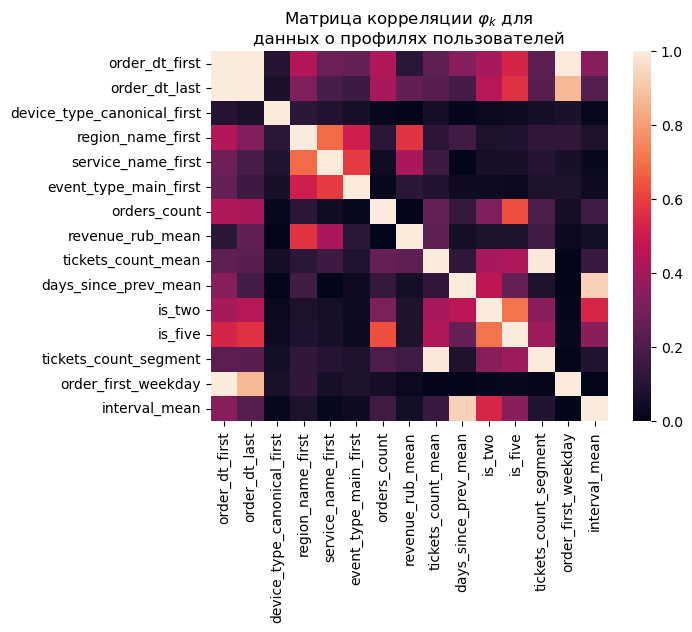

In [113]:
sns.heatmap(corr_matrix)

plt.title('Матрица корреляции $\\varphi_k$ для \nданных о профилях пользователей')

plt.show()

Проверим распределение пользователей по столбцу `orders_count`:

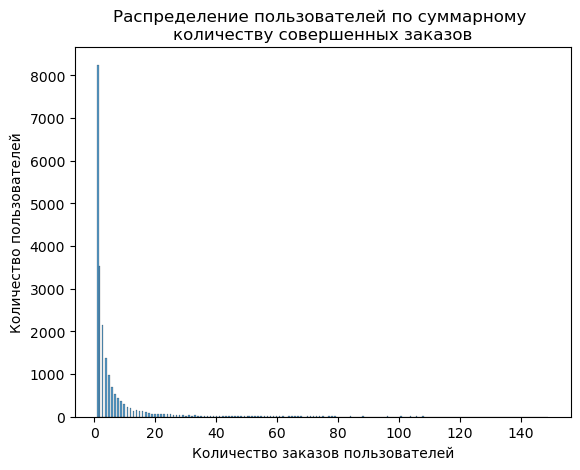

In [114]:
sns.histplot(df_agged['orders_count'])

plt.title('Распределение пользователей по суммарному \nколичеству совершенных заказов')
plt.xlabel('Количество заказов пользователей')
plt.ylabel('Количество пользователей')

plt.show()

Видно, что имеется огромное количество пользователей с маленьким числом заказов. Разделим столбец на категории:

In [115]:
bins = [0, 1, 4, np.inf]
labels = ['1', '2-4', '5+']

df_agged['orders_count_segment'] = pd.cut(df_agged['orders_count'], bins=bins, labels=labels).astype('category')

df_agged[['orders_count', 'orders_count_segment']].head(10)

,orders_count,orders_count_segment
user_id,,
0002849b70a3ce2,1,1
0005ca5e93f2cf4,2,2-4
000898990054619,3,2-4
00096d1f542ab2b,1,1
000a55a418c128c,2,2-4
000cf0659a9f40f,13,5+
00147c9209d45d3,2,2-4
00199a573901564,1,1
001e7037d013f0f,3,2-4


In [116]:
columns = df_agged.columns
columns = columns.drop('orders_count')
columns

Index(['order_dt_first', 'order_dt_last', 'device_type_canonical_first',
       'region_name_first', 'service_name_first', 'event_type_main_first',
       'revenue_rub_mean', 'tickets_count_mean', 'days_since_prev_mean',
       'is_two', 'is_five', 'tickets_count_segment', 'order_first_weekday',
       'interval_mean', 'orders_count_segment'],
      dtype='str')

In [117]:
corr_matrix = phik_matrix(df_agged[columns])

interval columns not set, guessing: ['revenue_rub_mean', 'tickets_count_mean', 'days_since_prev_mean', 'interval_mean']


Вновь построим матрицу:

In [118]:
corr_matrix

,order_dt_first,order_dt_last,device_type_canonical_first,region_name_first,service_name_first,event_type_main_first,revenue_rub_mean,tickets_count_mean,days_since_prev_mean,is_two,is_five,tickets_count_segment,order_first_weekday,interval_mean,orders_count_segment
order_dt_first,1.000000,0.998799,0.097520,0.446034,0.275137,0.259035,0.113079,0.242983,0.336421,0.412599,0.534265,0.240239,1.000000,0.336402,0.576853
order_dt_last,0.998799,1.000000,0.072000,0.321541,0.193094,0.162797,0.256801,0.234205,0.181798,0.451175,0.567601,0.231154,0.870145,0.219998,0.606987
device_type_canonical_first,0.097520,0.072000,1.000000,0.110774,0.087191,0.063131,0.006537,0.056825,0.009056,0.025679,0.032196,0.052791,0.070679,0.019744,0.012699
region_name_first,0.446034,0.321541,0.110774,1.000000,0.691036,0.512547,0.573055,0.113320,0.170277,0.077755,0.084093,0.129764,0.131092,0.076978,0.120824
service_name_first,0.275137,0.193094,0.087191,0.691036,1.000000,0.591802,0.422042,0.156953,0.000000,0.061807,0.065880,0.100026,0.063760,0.021973,0.093165
event_type_main_first,0.259035,0.162797,0.063131,0.512547,0.591802,1.000000,0.112142,0.086231,0.041567,0.033244,0.027427,0.075511,0.078989,0.040608,0.043004
revenue_rub_mean,0.113079,0.256801,0.006537,0.573055,0.422042,0.112142,1.000000,0.244399,0.054665,0.081745,0.078725,0.167430,0.030127,0.050933,0.086070
tickets_count_mean,0.242983,0.234205,0.056825,0.113320,0.156953,0.086231,0.244399,1.000000,0.125712,0.411106,0.430910,0.993392,0.000000,0.149706,0.405935
days_since_prev_mean,0.336421,0.181798,0.009056,0.170277,0.000000,0.041567,0.054665,0.125712,1.000000,0.467724,0.260312,0.080626,0.000000,0.932246,0.468579
is_two,0.412599,0.451175,0.025679,0.077755,0.061807,0.033244,0.081745,0.411106,0.467724,1.000000,0.705143,0.347416,0.013821,0.535852,1.000000


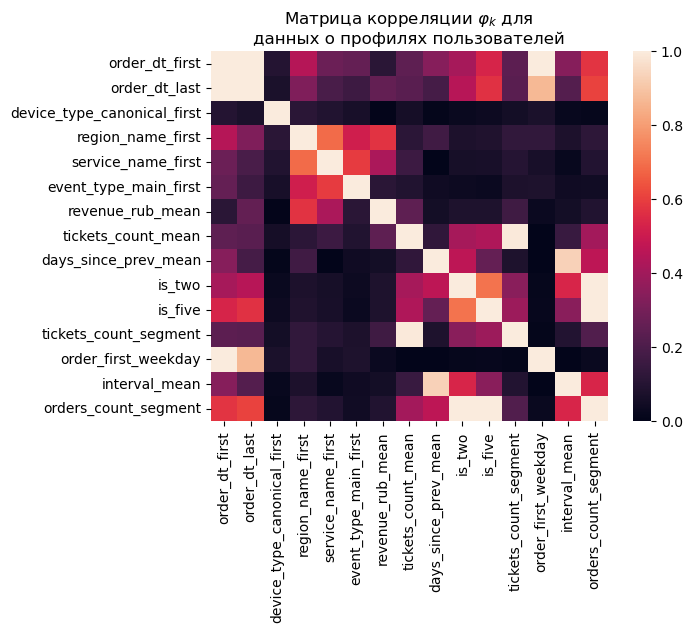

In [119]:
sns.heatmap(corr_matrix)

plt.title('Матрица корреляции $\\varphi_k$ для \nданных о профилях пользователей')

plt.show()

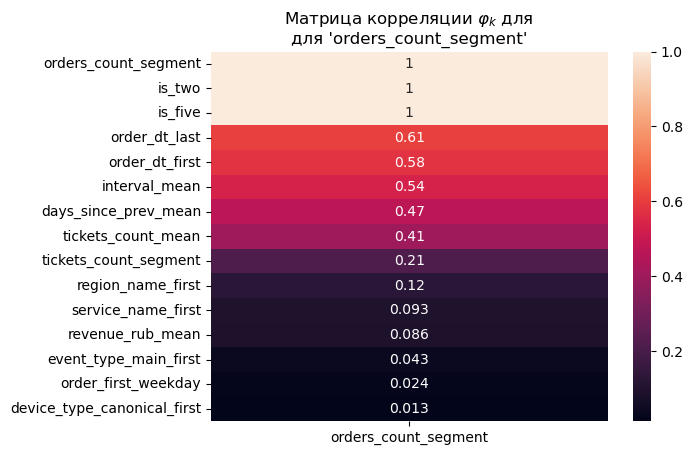

In [120]:
sns.heatmap(
    corr_matrix['orders_count_segment'].sort_values(ascending=False).to_frame(),
    annot=True
)

plt.title('Матрица корреляции $\\varphi_k$ для \nдля \'orders_count_segment\'')

plt.show()

In [121]:
corr_matrix['orders_count_segment'].reset_index().dtypes

index                       str
orders_count_segment    float64
dtype: object

Корреляция со столбцами `is_two` и `is_five` очевидна. Далее, взаимосвязь `orders_count_segment` с `order_dt_last` и `order_dt_first` также понятна: если пользователь рано завершит пользоваться услугами Афиши, то и заказов совершит немного. А вот средняя корреляция со столбцами `interval_mean` и `days_since_prev_mean` представляет интерес. Ранее мы выяснили, что пользователи, которые чаще совершают покупки, менее склонны к уходу с платформы, что и отражено в данной таблице.

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

##### Резюме

В ходе предобработки данных выручка была приведена к российскому  рублю; также были отфильтрованы выбросы по выручке с заказов, поскольку они не отражают средней ситуации по рынку.

Далее данные были агрегированы с целью получить профиль пользователей. К этим данным была добавлена информация о первом заказе.

##### Выводы

В ходе исследовательского анализа данных были выявлены следующие моменты:
1. в выборке представлена информация о $21347$ пользователях. Из них $8251$ ($38.7\%$) совершили один заказ, в то время как доля пользователей хотя бы с двумя заказами не превосходит и $17\%$
2. более всего на вероятность повторной покупки после первой влияют тип мероприятия: чаще возвращаются после посещения выставок, театров и концертов, — а также выбранный билетный оператор: у операторов "Зэ бест!", "Быстрый кассир" и "Билет по телефону" самая высокая конверсия
3. средняя выручка с клиента положительно коррелирует с вероятностью совершить повторную покупку: клиенты, совершающие более крупные покупки, с бóльшим шансом вернутся на Афишу. Кроме того, больше всего остаются те клиенты, которые в среднем приобретают от $2$ до $3$ билетов за заказ
4. чем более лояльный клиент, тем чаще он совершает покупки. Чаще всего клиенты приобретают билеты по четвергам, пяттницам и воскресеньям. Однако на повторный заказ время совершения первой покупки не влияет. Что подтверждается и корреляцонным анализом

##### Рекомендации

- следует обратить внимание на клиентов, которые приобратают на слишком малые суммы, а также менее $2$ и более $4$ билетов за раз: эта категория лиц наиболее склонная к уходу с платформы. Для таких клиентов можно предлагать более выгодные условия при покупке, например скидку на каждый следующий после пятого билет или бонус при покупке билета второй половинке (в случае если билет один)
- рекомендуется повышать популярность конверсионных билетных операторов, а также провести дополнительное исследование на тему, почему их сервис более качественный
- тип первого мероприятия, которое посетил клиент, также немаловажно. В связи с этим можно в качестве первого мероприятия более настойчиво предлагать популярные мероприятия по типу концертов или выставок, а только потом адаптировать рекомендации под нужды клиента
- также лучше следить за частотой совершения покупок на платформе. Если она снижается, можно выдвигать специальные, более выгодные, предложения для клиента 

### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**

Ссылочка: [https://github.com/ivmulin/afisha_analysis](https://github.com/ivmulin/afisha_analysis).